<a href="https://colab.research.google.com/github/Architag1503/Colab/blob/main/SilhouetteScore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score , silhouette_samples
from sklearn.preprocessing import StandardScaler

In [6]:
X , y = make_blobs(n_samples=600 , centers=4 , cluster_std=0.92 , random_state=42)
X

array([[-7.59151325, -8.02519192],
       [-6.61663103, -6.57240935],
       [-5.3473907 , -5.94688913],
       ...,
       [-3.01002973,  9.11633491],
       [-8.23819071,  5.87324213],
       [-3.28127774,  8.72981074]])

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df = pd.DataFrame(X_scaled , columns=['x1' , 'x2'])
df

,x1,x2
0,-0.813159,-1.751703
1,-0.626116,-1.518392
2,-0.382596,-1.417936
3,-0.270788,-1.621417
4,1.550831,-0.260219
...,...,...
595,-1.033984,0.703988
596,-0.778183,-1.549781
597,0.065857,1.001155
598,-0.937232,0.480327


In [11]:
range_n_clusters = [2 , 3 , 4 , 5 , 6 , 7 , 8 , 9 , 10 , 11 , 12]

best_K = 0;
best_score = -1

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k , random_state=42)
    labels = kmeans.fit_predict(df)

    score = silhouette_score(df , labels)
    print(f"k = {k} , Silhouette Score = {score}")

    if score > best_score:
        best_score = score
        best_K = k

print(f"Best K = {best_K} , Best Score = {best_score}")

k = 2 , Silhouette Score = 0.5315117042824878
k = 3 , Silhouette Score = 0.7506070082841285
k = 4 , Silhouette Score = 0.8114273690508504
k = 5 , Silhouette Score = 0.6924519337382288
k = 6 , Silhouette Score = 0.5849449939125129
k = 7 , Silhouette Score = 0.46590871020979546
k = 8 , Silhouette Score = 0.43214656824791786
k = 9 , Silhouette Score = 0.4381117822561123
k = 10 , Silhouette Score = 0.33442448824507615
k = 11 , Silhouette Score = 0.3476082023677332
k = 12 , Silhouette Score = 0.34295537546992627
Best K = 4 , Best Score = 0.8114273690508504


In [12]:
Kmeans = KMeans(n_clusters=best_K , random_state=42)
labels = Kmeans.fit_predict(df)

In [13]:
sample_silhouette_values = silhouette_samples(df , labels)

plt.figure(figsize=(10 , 10))
y_lower = 10

<Figure size 1000x1000 with 0 Axes>

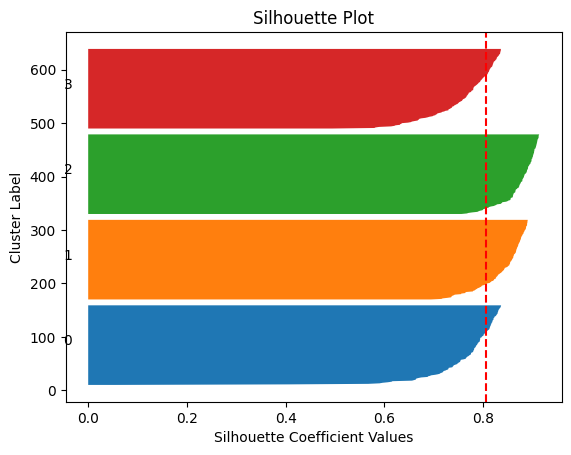

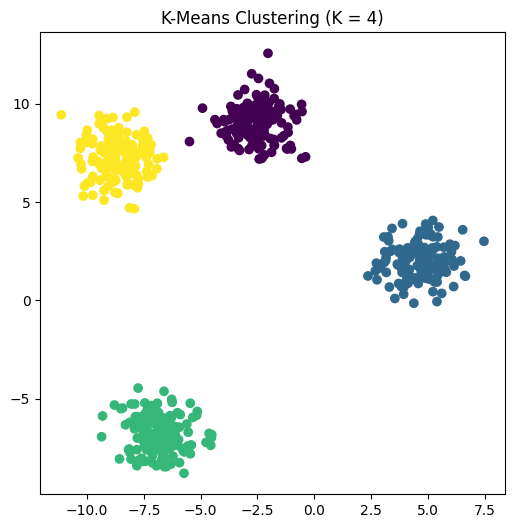

In [14]:
for i in range(best_K):
  ith_cluster_values = sample_silhouette_values[labels == i]
  ith_cluster_values.sort()

  size_cluster_i = ith_cluster_values.shape[0]
  y_upper = y_lower + size_cluster_i

  plt.fill_betweenx(np.arange(y_lower , y_upper) , 0 , ith_cluster_values)
  plt.text(-0.05 , y_lower + 0.5 * size_cluster_i , str(i))
  y_lower = y_upper + 10

plt.title("Silhouette Plot")
plt.xlabel("Silhouette Coefficient Values")
plt.ylabel("Cluster Label")

avg_score = silhouette_score(X, labels)
plt.axvline(x=avg_score, color="red", linestyle="--")

plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.title(f"K-Means Clustering (K = {best_K})")
plt.show()
